In [15]:
from functools import total_ordering
from math import inf

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import cv2
import scipy.ndimage
from numpy import convolve
from skimage.filters import threshold_otsu, gaussian
from skimage.morphology import binary_opening, binary_closing, disk
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import os
from skimage.filters import frangi
from skimage.feature import canny
from skimage.transform import probabilistic_hough_line
from skimage.morphology import skeletonize
from skimage.exposure import rescale_intensity
from skimage.filters import threshold_otsu

from scipy.ndimage import convolve
import math
from itertools import combinations

from skimage.measure import shannon_entropy
from skimage.filters.rank import entropy
from skimage.morphology import disk
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from skimage.measure import label, regionprops

import torch
import torch.nn as nn
import torch.nn.functional as F

import joblib
import numpy as np




def show_3x3(images, start=0):
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))

    for i, ax in enumerate(axes.flat):
        idx = start + i
        if idx >= len(images):
            ax.axis("off")
            continue

        ax.imshow(images[idx], cmap='gray')
        ax.set_title(f"img {idx}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def show(image):
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.show()

def show_skeleton(img, skel):
    skel = skel.astype(bool)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    # original
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title("Original")
    ax[0].axis("off")

    # skeleton only (red)
    ax[1].imshow(skel, cmap='gray')  # base just to set geometry
    ax[1].imshow(skel, cmap='Reds')  # red skeleton
    ax[1].set_title("Skeleton")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()


In [16]:
import matplotlib.pyplot as plt
import os
from skimage.measure import label
import math
from skimage.measure import label, regionprops
import numpy as np
import cv2

def get_data(type, duplicate=True):
    metadata: dict[str, list[float]] = dict()
    meta_dict: dict[str, dict[str, float]] = dict()

    path = "TRAIN_SET"

    types  = sorted(os.listdir(path))
    print(types)

    def load_real_size(path) -> float:
        with open(path, "r", encoding="latin1", errors="ignore") as f:
            for line in f:
                line = line.strip()

                if line.startswith(r"\Scan Size:"):
                    # example: \Scan Size: 92516.8 nm
                    parts = line.split(":")[1].strip().split()
                    return float(parts[0])  # value in nm

        assert False

    def should_ignore(size):
        return size < 25000

    # loading metadata
    metadata_type = []
    loadpath = path + "/" + type
    meta_dict_type = dict()

    for filename in sorted(os.listdir(loadpath)):
        full_path = os.path.join(loadpath, filename)

        if filename.lower().endswith(".bmp") or  filename.lower().endswith(".bin"):
            continue

        # // check  if there exists a file called filename + "_1.bmp"
        bmp_path = os.path.join(loadpath, filename + "_1.bmp")
        if not os.path.exists(bmp_path):
            print(f"{bmp_path} doesnt exist")
            continue

        size: float = load_real_size(full_path)
        if should_ignore(size):
            print(f"{filename} Ignored! Size {size} too small!")
            continue

        metadata_type.append(size)
        # debug
        meta_dict_type[filename] = size

    meta_dict[type] = meta_dict_type
    metadata[type] = metadata_type;


    print(f"Loaded {len(metadata_type)} images of {type}")

    # loading images and filtering if metadata are available
    images: dict = dict()
    filenames : dict = dict()

    images_type = []
    filenames_type = []
    loadpath = path + "/" + type

    for filename in sorted(os.listdir(loadpath)):
        if filename.lower().endswith(".bmp"):
           # // check  if there exists a file called filename + "_1.bmp"
            meta_path = os.path.join(loadpath, filename.replace("_1.bmp", ""))
            if not os.path.exists(meta_path):
                print(f"{meta_path} doesnt exist!!")
                continue
            if not  filename.replace("_1.bmp", "") in meta_dict[type]:
                print(f"{filename.replace("_1.bmp", "")}  is not existent!!")
                continue

            full_path = os.path.join(loadpath, filename)
            img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                images_type.append(img)
                filenames_type.append(filename)

    print(f"Loaded {len(images_type)} images of {type}")

    # Convert to numpy array (if all same shape)
    images_type = np.array(images_type)
    images[type] = images_type
    filenames[type] = filenames_type


    def crop_image(image_to_crop, top = 10, bottom =  575 - 45, left = 94, right = 704 - 90):
        return image_to_crop[top:bottom, left:right]

    def crop_images(to_crop: list[np.ndarray]):
        cropped = []
        for _img in to_crop:
            cropped.append(crop_image(_img))

        return np.array(cropped, dtype=np.uint8)

    from skimage.morphology import skeletonize
    from skimage.exposure import rescale_intensity
    from skimage.filters import threshold_otsu

    def change_contrast(image, low=10, high=98):
        p_low, p_high = np.percentile(image, (low, high))
        return rescale_intensity(image, in_range=(p_low, p_high))

    def process_skeletons(to_skeletonize):
        processed = []
        skeletons = []
        for img in to_skeletonize:
            img = change_contrast(img)
            th = threshold_otsu(img)
            binary = img > th

            skel = skeletonize(binary)
            skeletons.append(skel)
            processed.append(binary)

        return processed, skeletons

    def normalize(images, metadatas, target=50000.0):
        added_by_cropping = 0

        out = []

        for i in range(len(images)):
            img = images[i]
            area = metadatas[i]

            ratio = target / area  # >1 enlarge, <1 shrink
            h, w = img.shape[:2]

            # # -------------------------
            # # 1. SCALE UP (small images)
            # # -------------------------
            # # 385 is aproximately  50000/92500
            if area < 51000:
                new_w = int(281.0)
                new_h = int(281.0)

                resized = cv2.resize(
                    img,
                    (new_w, new_h),
                    interpolation=cv2.INTER_NEAREST
                )

                out.append(resized)
            # # -------------------------
            # 2. CROP (large images)
            # -------------------------
            else:
                new_w = int(w * ratio)
                new_h = int(h * ratio)
                # center crop
                start_x = (w - new_w) // 2
                start_y = (h - new_h) // 2

                cropped_center = img[
                    start_y:start_y + new_h,
                    start_x:start_x + new_w
                ]
                cropped_tl = img[0:new_h, 0:new_w]
                cropped_tr = img[0:new_h, w-new_w:w]
                cropped_bl = img[h-new_h:h, 0:new_w]
                cropped_br = img[h-new_h:h, w-new_w:w]

                if not duplicate:
                    out.append(cropped_center)
                else:
                    out.append(cropped_tl)
                    out.append(cropped_tr)
                    out.append(cropped_bl)
                    out.append(cropped_br)
                    added_by_cropping += 3

        print(f"Pocet pridaných navyše obrázkov stvtenim {int(added_by_cropping)}")
        return np.array(out)

    normalized: dict[str, list] = dict()

    cropped = crop_images(images[type])

    normalized[type] = normalize(cropped, metadata[type])

    raw_images = normalized[type]

    processed, skeletons = process_skeletons(raw_images)

    return raw_images, processed, skeletons

rows = []

for type in sorted(os.listdir("TRAIN_SET")):
    duplicate = True
    if type == "SklerózaMultiplex":
        duplicate = False
    cropped, processed, skeletons = get_data(type, duplicate=duplicate)
    # show_3x3(cropped, 0)
    rows.append({
        "type": type,
        "cropped_count": len(cropped)
    })
    #
    # shapes = [img.shape[:2] for img in cropped] # # (h, w)
    # min_h, min_w = np.min(shapes, axis=0)
    # max_h, max_w = np.max(shapes, axis=0)
    # print(f"Min shape: {(min_h, min_w)}")
    # print(f"Max shape: {(max_h, max_w)}")

df = pd.DataFrame(rows)
print(df)
# #

['Diabetes', 'PGOV_Glaukom', 'SklerózaMultiplex', 'SucheOko', 'ZdraviLudia']
Loaded 26 images of Diabetes
37_DM_.bmp  is not existent!!
Loaded 26 images of Diabetes
Pocet pridaných navyše obrázkov stvtenim 69
['Diabetes', 'PGOV_Glaukom', 'SklerózaMultiplex', 'SucheOko', 'ZdraviLudia']
TRAIN_SET/PGOV_Glaukom/25_PV_PGOV.017_1.bmp doesnt exist
Loaded 35 images of PGOV_Glaukom
Loaded 35 images of PGOV_Glaukom
Pocet pridaných navyše obrázkov stvtenim 99
['Diabetes', 'PGOV_Glaukom', 'SklerózaMultiplex', 'SucheOko', 'ZdraviLudia']
1-SM-LM-18.027 Ignored! Size 20000.0 too small!
1-SM-LM-18.029 Ignored! Size 20000.0 too small!
1-SM-LM-18.030 Ignored! Size 10000.0 too small!
1-SM-PM-18.003 Ignored! Size 20000.0 too small!
1-SM-PM-18.007 Ignored! Size 20000.0 too small!
19_PM_SM.001 Ignored! Size 20000.0 too small!
19_PM_SM.066 Ignored! Size 10000.0 too small!
19_PM_SM.072 Ignored! Size 20000.0 too small!
20_LM_SM-SS.004 Ignored! Size 10000.0 too small!
20_LM_SM-SS.011 Ignored! Size 20000.0 too s

In [17]:

def get_spot_count(img):
    SPOT_SIZE = 3

    def get_spot_contrast(gray, binary, x, y, spot_size, n):
        sum_spot = 0.0
        sum_out = 0.0

        count_spot = 0
        count_out = 0

        h, w = gray.shape

        for i in range(x - n - spot_size, x + n + spot_size + 1):
            for j in range(y - n - spot_size, y + n + spot_size + 1):

                if not (0 <= i < w and 0 <= j < h):
                    continue

                val = float(gray[j, i])

                # inside square spot
                if binary[j][i]:
                    sum_spot += val
                    count_spot += 1
                else:
                    sum_out += val
                    count_out += 1

        if count_spot == 0 or count_out == 0:
            return 0

        mean_spot = sum_spot / count_spot
        mean_out = sum_out / count_out

        return mean_spot / mean_out

    gray = img

    kernel = np.ones((25, 25), np.uint8)
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    tophat = cv2.GaussianBlur(tophat, (5, 5), 0)

    n = 100
    flat = gray.flatten()
    idx = np.argsort(flat)[:n]   # indices of n darkest pixels
    values = flat[idx]
    avg_n_min = np.mean(values)
    _, binary = cv2.threshold(tophat, int(110) - avg_n_min, 255, cv2.THRESH_BINARY)

    kernel_small = np.ones((SPOT_SIZE, SPOT_SIZE), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_small, iterations=1)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)

    spots = []

    for j in range(1, num_labels):
        area = stats[j, cv2.CC_STAT_AREA]

        if area > 0 and area < 10:
            x, y = centroids[j]

            if gray[int(y), int(x)] > 180 and get_spot_contrast(tophat, binary, int(x), int(y), SPOT_SIZE, 2) > 1.8:
                spots.append((int(x), int(y), area))

    output = img.copy()
    for x, y, area in spots:
        cv2.circle(output, (x, y), 6, (0, 0, 255), 2)
        cv2.putText(output, f"{area}", (x + 5, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0),
                    1)  # ------------------------- # Step 8: show # -------------------------

    #
    # cv2.imshow("Top-hat", tophat)
    # cv2.imshow("Binary", binary)
    # cv2.imshow("Bright spots", output)
    # cv2.waitKey(0)

    return len(spots)

def get_spot_count_all(images):
    return np.array([get_spot_count(image) for image in images])

In [18]:
from skimage.measure import shannon_entropy

import warnings


def count_components(skeleton, min_size = 5, max_size=math.inf):
    labeled = label(skeleton, connectivity=2)

    count = 0
    for r in regionprops(labeled):
        if min_size < r.area < max_size:
            count += 1

    return count

def count_components_all(skeletons):
    return np.array([count_components(skeleton) for skeleton in skeletons])

def branching_factor(skeleton):
    """
    Compute branching factor of a skeleton.

    Parameters:
        skeleton (np.ndarray): binary image (bool or 0/1)

    Returns:
        float: branching factor (junctions / endpoints)
        dict: detailed counts
    """

    skel = skeleton.astype(np.uint8)

    # 8-neighborhood kernel (center excluded)
    kernel = np.array([
        [1,1,1],
        [1,0,1],
        [1,1,1]
    ])

    # count neighbors for each pixel
    neighbor_count = scipy.ndimage.convolve(skel, kernel, mode='constant', cval=0)

    # only consider skeleton pixels
    degrees = neighbor_count * skel

    endpoints = np.sum(degrees == 1)
    junctions = np.sum(degrees >= 3)
    normal = np.sum(degrees == 2)

    # avoid division by zero
    bf = (junctions / endpoints) if endpoints > 0 else 0.0

    return bf

def fft_metric(cropped_image):
    line_thickness = 20

    f_transform = np.fft.fft2(cropped_image)
    f_transform_shifted = np.fft.fftshift(f_transform)
    log_magnitude = np.log(np.abs(f_transform_shifted) + 1e-8)

    height, width = cropped_image.shape
    cy, cx = height // 2, width // 2
    mask_radius = 100
    percentile = 70

    y, x = np.ogrid[-cy:height - cy, -cx:width - cx]
    distance_from_center = np.sqrt(x ** 2 + y ** 2)
    min_val = np.min(log_magnitude)
    log_magnitude[distance_from_center <= mask_radius] = min_val

    threshold_value = np.percentile(log_magnitude, percentile)
    binary_fft = (log_magnitude >= threshold_value).astype(int)

    cross_mask = np.zeros_like(binary_fft)
    cross_mask[cy - line_thickness: cy + line_thickness + 1, :] = 1
    cross_mask[:, cx - line_thickness: cx + line_thickness + 1] = 1

    pixels_in_cross = np.sum(binary_fft * cross_mask)
    total_white_pixels = np.sum(binary_fft)

    return pixels_in_cross / (total_white_pixels + 1e-10)

def box_counting_fractal_dimension(image_array):
    """
    Calculates the fractal dimension of a 2D image using the box-counting method.

    Parameters:
    - image_array: 2D NumPy array (can be binary or grayscale, will be binarized > 0)

    Returns:
    - fd: The fractal dimension (float), typically between 1.0 and 2.0.
    """
    # 1. Ensure the image is strictly binary (background=0, crystal=1)
    Z = (image_array > 0)

    # Extract the Y, X coordinates of all crystal pixels
    pixels = np.argwhere(Z)
    if len(pixels) == 0:
        return 0.0  # Return 0 if the image is completely empty

    Ly, Lx = Z.shape

    # 2. Define the varying box sizes
    # We create a logarithmic scale of box sizes from 1 pixel up to 1/5th of the image size
    max_box_size = min(Lx, Ly) // 5
    # Generate logarithmically spaced sizes and ensure they are unique integers
    sizes = np.logspace(0.1, np.log10(max_box_size), num=20, base=10)
    sizes = np.unique(np.floor(sizes)).astype(int)

    counts = []

    # 3. Count the boxes for each grid size
    for size in sizes:
        # Determine the number of boxes in X and Y directions
        Nx = int(np.ceil(Lx / size))
        Ny = int(np.ceil(Ly / size))

        # Create the grid boundaries (bins)
        xbins = np.arange(0, Nx * size + 1, size)
        ybins = np.arange(0, Ny * size + 1, size)

        # Drop the pixels into the grid using a 2D histogram
        H, _, _ = np.histogram2d(pixels[:, 0], pixels[:, 1], bins=(ybins, xbins))

        # Count how many boxes contain at least 1 pixel (H > 0)
        counts.append(np.sum(H > 0))

    # 4. Calculate the slope of the line of best fit (Fractal Dimension)
    # x-axis: log(1 / box_size)
    # y-axis: log(number of filled boxes)
    x_vals = np.log(1.0 / sizes)
    y_vals = np.log(counts)

    # np.polyfit returns [slope, intercept]
    coeffs = np.polyfit(x_vals, y_vals, 1)
    fractal_dimension = coeffs[0]

    return fractal_dimension


def calculate_skeleton_entropies(skeleton_array):
    """
    Calculates both Global and Local entropy for a binary skeleton image.
    """
    # 1. Global Binary Entropy (Effectively measures Skeleton Density)
    global_ent = shannon_entropy(skeleton_array)

    # 2. Local Spatial Entropy (Measures structural chaos)
    # Convert skeleton to an 8-bit integer array as required by skimage rank filters
    skel_8bit = (skeleton_array > 0).astype(np.uint8) * 255

    # Define the neighborhood size (a circle with a radius of 10 pixels)
    neighborhood = disk(10)

    # Calculate entropy for every local neighborhood
    # Catching warnings here because pure black regions might throw a low-contrast warning
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        local_ent_map = entropy(skel_8bit, neighborhood)

    # The final feature is the average chaos across the entire image
    mean_local_ent = np.mean(local_ent_map)

    return global_ent, mean_local_ent

def bf_all(skeletons):
    out = []
    for skell in skeletons:
        out.append(branching_factor(skell))
    return np.array(out)

import os
import numpy as np
import matplotlib.pyplot as plt

types = []
mean_counts = []
all_counts = []
cropped_list = []
processed_list = []
skeleton_list = []
bf_list = []
spot_count_list = []

fft_vals_list = []
fd_bin_list = []
fd_skel_list = []
glob_ent_bin_list = []
loc_ent_bin_list = []
glob_ent_skel_list = []
loc_ent_skel_list = []

for type in sorted(os.listdir("TRAIN_SET")):
    duplicate = True
    if type == "SklerózaMultiplex":
        duplicate = False

    cropped, processed, skeletons = get_data(type, duplicate=duplicate)
    counts = count_components_all(skeletons)
    spot_counts = get_spot_count_all(cropped)
    fft_val = np.array([fft_metric(crop) for crop in cropped])
    fd_bin = np.array([box_counting_fractal_dimension(proc) for proc in processed])
    fd_skel = np.array([box_counting_fractal_dimension(skel) for skel in skeletons])
    glob_ent_bin = np.array([calculate_skeleton_entropies(crop)[0] for crop in cropped])
    loc_ent_bin = np.array([calculate_skeleton_entropies(crop)[1] for crop in cropped])

    glob_ent_skel= np.array([calculate_skeleton_entropies(skel)[0] for skel in skeletons])
    loc_ent_skel = np.array([calculate_skeleton_entropies(skel)[1] for skel in skeletons])

    fft_vals_list.append(fft_val)
    fd_bin_list.append(fd_bin)
    fd_skel_list.append(fd_skel)
    glob_ent_bin_list.append(glob_ent_bin)
    loc_ent_bin_list.append(loc_ent_bin)
    glob_ent_skel_list.append(glob_ent_skel)
    loc_ent_skel_list.append(loc_ent_skel)

    spot_count_list.append(spot_counts)
    cropped_list.append(cropped)
    processed_list.append(processed)
    skeleton_list.append(skeletons)
    bf_list.append(bf_all(skeletons))

    types.append(type)
    mean_counts.append(np.mean(counts))
    all_counts.append(counts)




['Diabetes', 'PGOV_Glaukom', 'SklerózaMultiplex', 'SucheOko', 'ZdraviLudia']
Loaded 26 images of Diabetes
37_DM_.bmp  is not existent!!
Loaded 26 images of Diabetes
Pocet pridaných navyše obrázkov stvtenim 69
['Diabetes', 'PGOV_Glaukom', 'SklerózaMultiplex', 'SucheOko', 'ZdraviLudia']
TRAIN_SET/PGOV_Glaukom/25_PV_PGOV.017_1.bmp doesnt exist
Loaded 35 images of PGOV_Glaukom
Loaded 35 images of PGOV_Glaukom
Pocet pridaných navyše obrázkov stvtenim 99
['Diabetes', 'PGOV_Glaukom', 'SklerózaMultiplex', 'SucheOko', 'ZdraviLudia']
1-SM-LM-18.027 Ignored! Size 20000.0 too small!
1-SM-LM-18.029 Ignored! Size 20000.0 too small!
1-SM-LM-18.030 Ignored! Size 10000.0 too small!
1-SM-PM-18.003 Ignored! Size 20000.0 too small!
1-SM-PM-18.007 Ignored! Size 20000.0 too small!
19_PM_SM.001 Ignored! Size 20000.0 too small!
19_PM_SM.066 Ignored! Size 10000.0 too small!
19_PM_SM.072 Ignored! Size 20000.0 too small!
20_LM_SM-SS.004 Ignored! Size 10000.0 too small!
20_LM_SM-SS.011 Ignored! Size 20000.0 too s

5


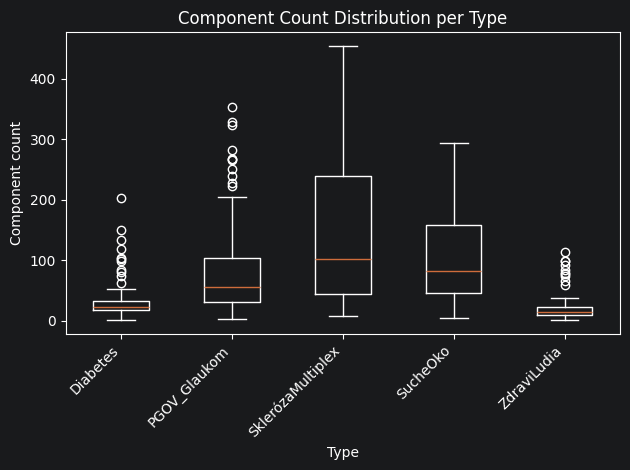

In [19]:
print(len(all_counts))
# plot
plt.figure()
plt.boxplot(all_counts, tick_labels=types)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Component count")
plt.xlabel("Type")
plt.title("Component Count Distribution per Type")

plt.tight_layout()
plt.show()


5
5


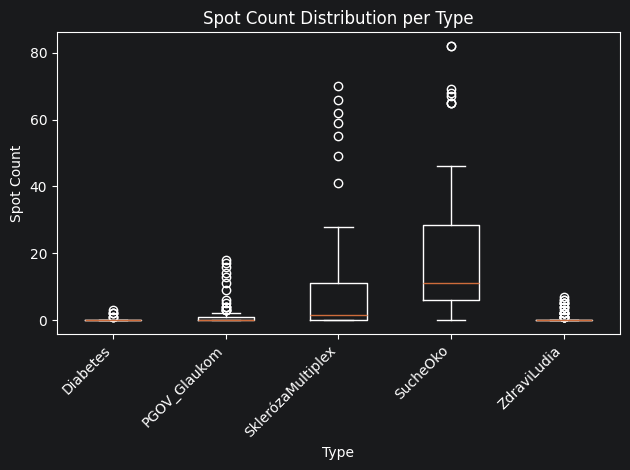

In [20]:
print(len(spot_count_list))

print(len(types))

# plot
plt.figure()
plt.boxplot(spot_count_list, tick_labels=types)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Spot Count")
plt.xlabel("Type")
plt.title("Spot Count Distribution per Type")

plt.tight_layout()
plt.show()


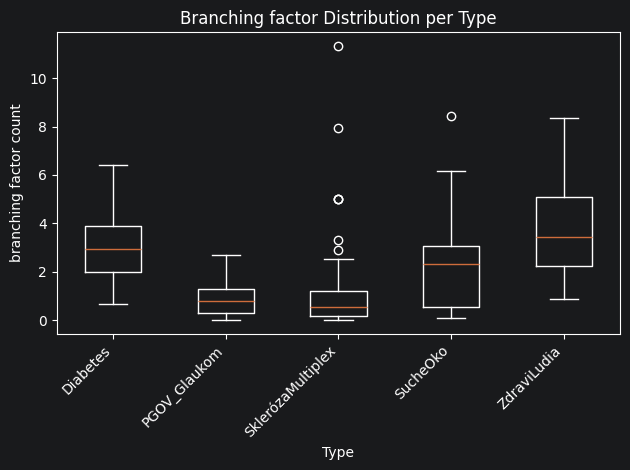

In [21]:
# plot
plt.figure()
plt.boxplot(bf_list, tick_labels=types)

plt.xticks(rotation=45, ha='right')
plt.ylabel("branching factor count")
plt.xlabel("Type")
plt.title("Branching factor Distribution per Type")

plt.tight_layout()
plt.show()

5


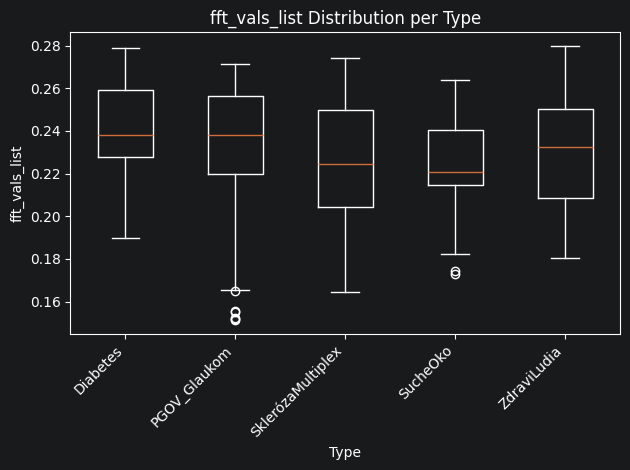

In [29]:
print(len(fft_vals_list))
# fd_bin_list.append(fd_bin)
# fd_skel_list.append(fd_skel)
# glob_ent_bin_list.append(glob_ent_bin)
# loc_ent_bin_list.append(loc_ent_bin)
# glob_ent_skel_list.append(glob_ent_skel)
# loc_ent_skel_list.append(loc_ent_skel)
# plot
plt.figure()
plt.boxplot(fft_vals_list, tick_labels=types)

plt.xticks(rotation=45, ha='right')
plt.ylabel("fft_vals_list")
plt.xlabel("Type")
plt.title("fft_vals_list Distribution per Type")

plt.tight_layout()
plt.show()

5


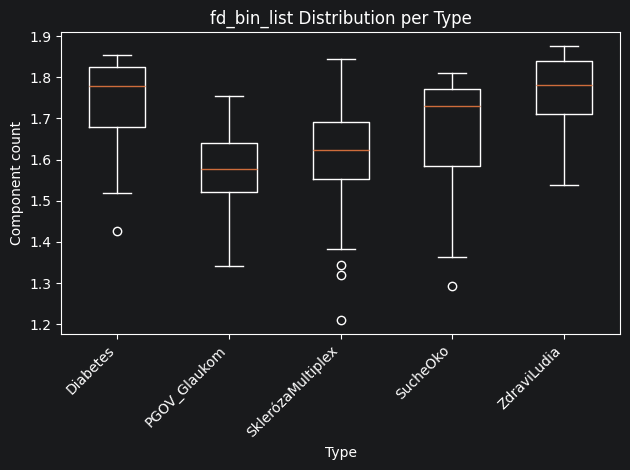

In [23]:
print(len(fd_bin_list))
# fd_skel_list.append(fd_skel)
# glob_ent_bin_list.append(glob_ent_bin)
# loc_ent_bin_list.append(loc_ent_bin)
# glob_ent_skel_list.append(glob_ent_skel)
# loc_ent_skel_list.append(loc_ent_skel)
# plot
plt.figure()
plt.boxplot(fd_bin_list, tick_labels=types)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Component count")
plt.xlabel("Type")
plt.title("fd_bin_list Distribution per Type")

plt.tight_layout()
plt.show()

5


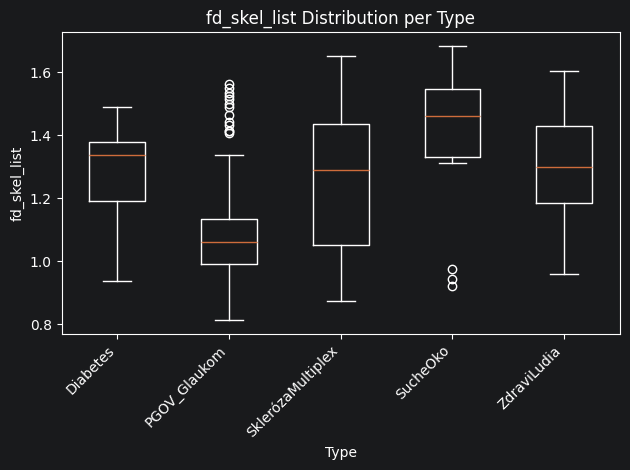

In [24]:
print(len(fd_skel_list))
# glob_ent_bin_list.append(glob_ent_bin)
# loc_ent_bin_list.append(loc_ent_bin)
# glob_ent_skel_list.append(glob_ent_skel)
# loc_ent_skel_list.append(loc_ent_skel)
# plot
plt.figure()
plt.boxplot(fd_skel_list, tick_labels=types)

plt.xticks(rotation=45, ha='right')
plt.ylabel("fd_skel_list")
plt.xlabel("Type")
plt.title("fd_skel_list Distribution per Type")

plt.tight_layout()
plt.show()

5


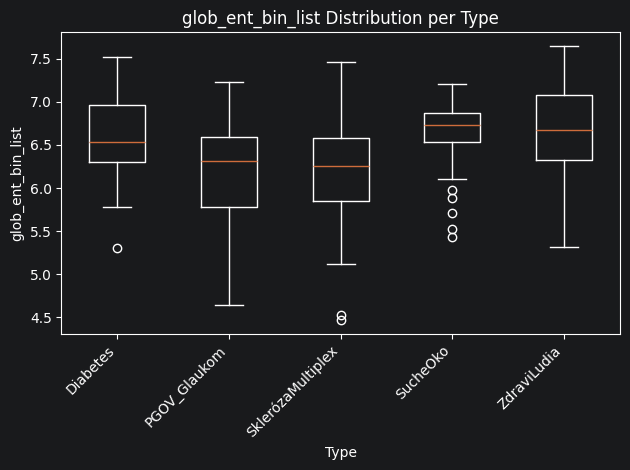

In [25]:
print(len(glob_ent_bin_list))
# loc_ent_bin_list.append(loc_ent_bin)
# glob_ent_skel_list.append(glob_ent_skel)
# loc_ent_skel_list.append(loc_ent_skel)
# plot
plt.figure()
plt.boxplot(glob_ent_bin_list, tick_labels=types)

plt.xticks(rotation=45, ha='right')
plt.ylabel("glob_ent_bin_list")
plt.xlabel("Type")
plt.title("glob_ent_bin_list Distribution per Type")

plt.tight_layout()
plt.show()

5


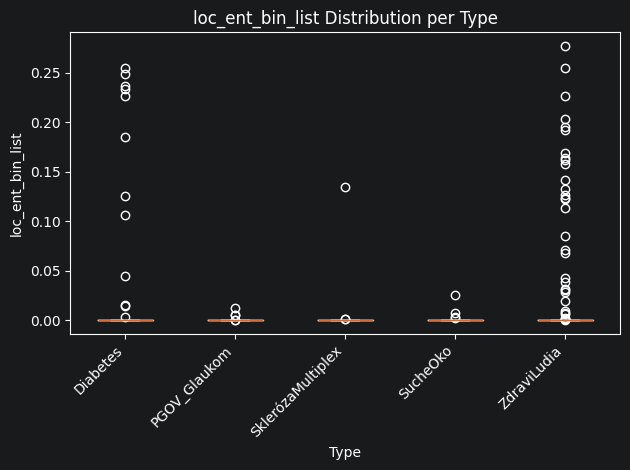

In [26]:
print(len(loc_ent_bin_list))
# glob_ent_skel_list.append(glob_ent_skel)
# loc_ent_skel_list.append(loc_ent_skel)
# plot
plt.figure()
plt.boxplot(loc_ent_bin_list, tick_labels=types)

plt.xticks(rotation=45, ha='right')
plt.ylabel("loc_ent_bin_list")
plt.xlabel("Type")
plt.title("loc_ent_bin_list Distribution per Type")

plt.tight_layout()
plt.show()

5


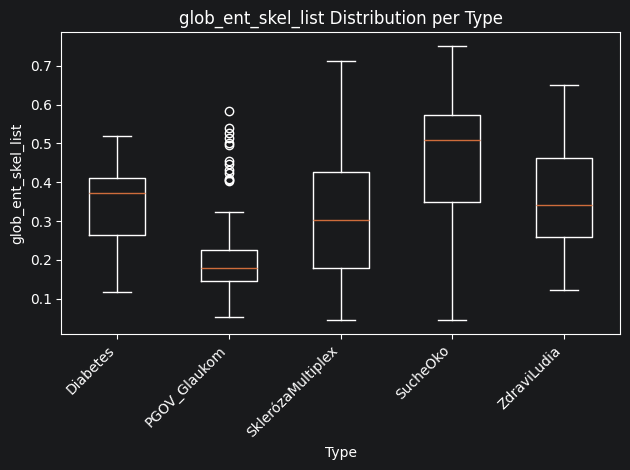

In [27]:
print(len(glob_ent_skel_list))
# loc_ent_skel_list.append(loc_ent_skel)
# plot
plt.figure()
plt.boxplot(glob_ent_skel_list, tick_labels=types)

plt.xticks(rotation=45, ha='right')
plt.ylabel("glob_ent_skel_list")
plt.xlabel("Type")
plt.title("glob_ent_skel_list Distribution per Type")

plt.tight_layout()
plt.show()

5


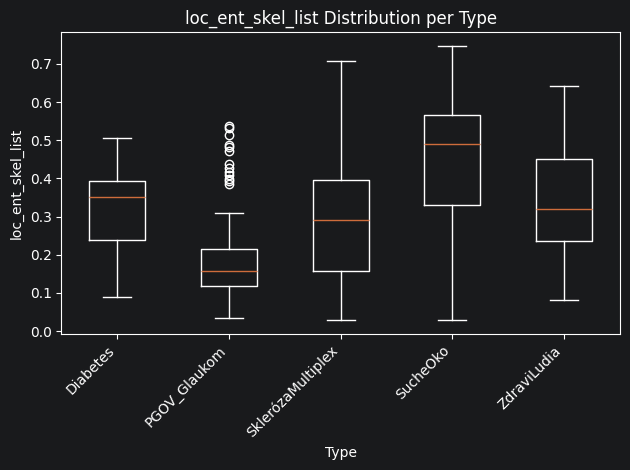

In [28]:
print(len(loc_ent_skel_list))

# plot
plt.figure()
plt.boxplot(loc_ent_skel_list, tick_labels=types)

plt.xticks(rotation=45, ha='right')
plt.ylabel("loc_ent_skel_list")
plt.xlabel("Type")
plt.title("loc_ent_skel_list Distribution per Type")

plt.tight_layout()
plt.show()